In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Mount Google Drive (Colab specific)
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
file_path = '/content/drive/MyDrive/University_Files/ML_Final_Project/titanic-kaggle-main/titanic.csv'
df = pd.read_csv(file_path)

# Display dataset basic info (For section 1-1 of your report)
print(f"Dataset Size: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Data Types:\n", df.dtypes, "\n")
print("Missing Values:\n", df.isnull().sum())
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Size: 891 rows, 12 columns

Data Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object 

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<div dir="rtl" style="text-align: right;">

### ۱-۱ معرفی مجموعه داده (Dataset Introduction)

مجموعه داده انتخاب شده مربوط به پیش‌بینی «بقای مسافران تایتانیک» است. بر اساس بررسی‌های اولیه، مشخصات این دیتاست به شرح زیر است:

* **اندازه دیتاست:** این دیتاست شامل ۸۹۱ سطر (نمونه) و ۱۲ ستون (ویژگی) است.
* **انواع ویژگی‌ها:** ویژگی‌های این مجموعه داده به دو دسته اصلی تقسیم می‌شوند:
  * **عددی (Numeric):** `PassengerId`, `Pclass` (رتبه‌ای)، `Age`، `SibSp`، `Parch`، و `Fare`.
  * **دسته‌ای و متنی (Categorical/Text):** `Name`، `Sex`، `Ticket`، `Cabin`، و `Embarked`.
* **متغیر هدف (Target Variable):** متغیر هدف در این مسئله ستون `Survived` است که دو کلاس دارد:
  * کلاس `0`: مسافرانی که جان خود را از دست دادند.
  * کلاس `1`: مسافرانی که نجات یافتند.
  </div>

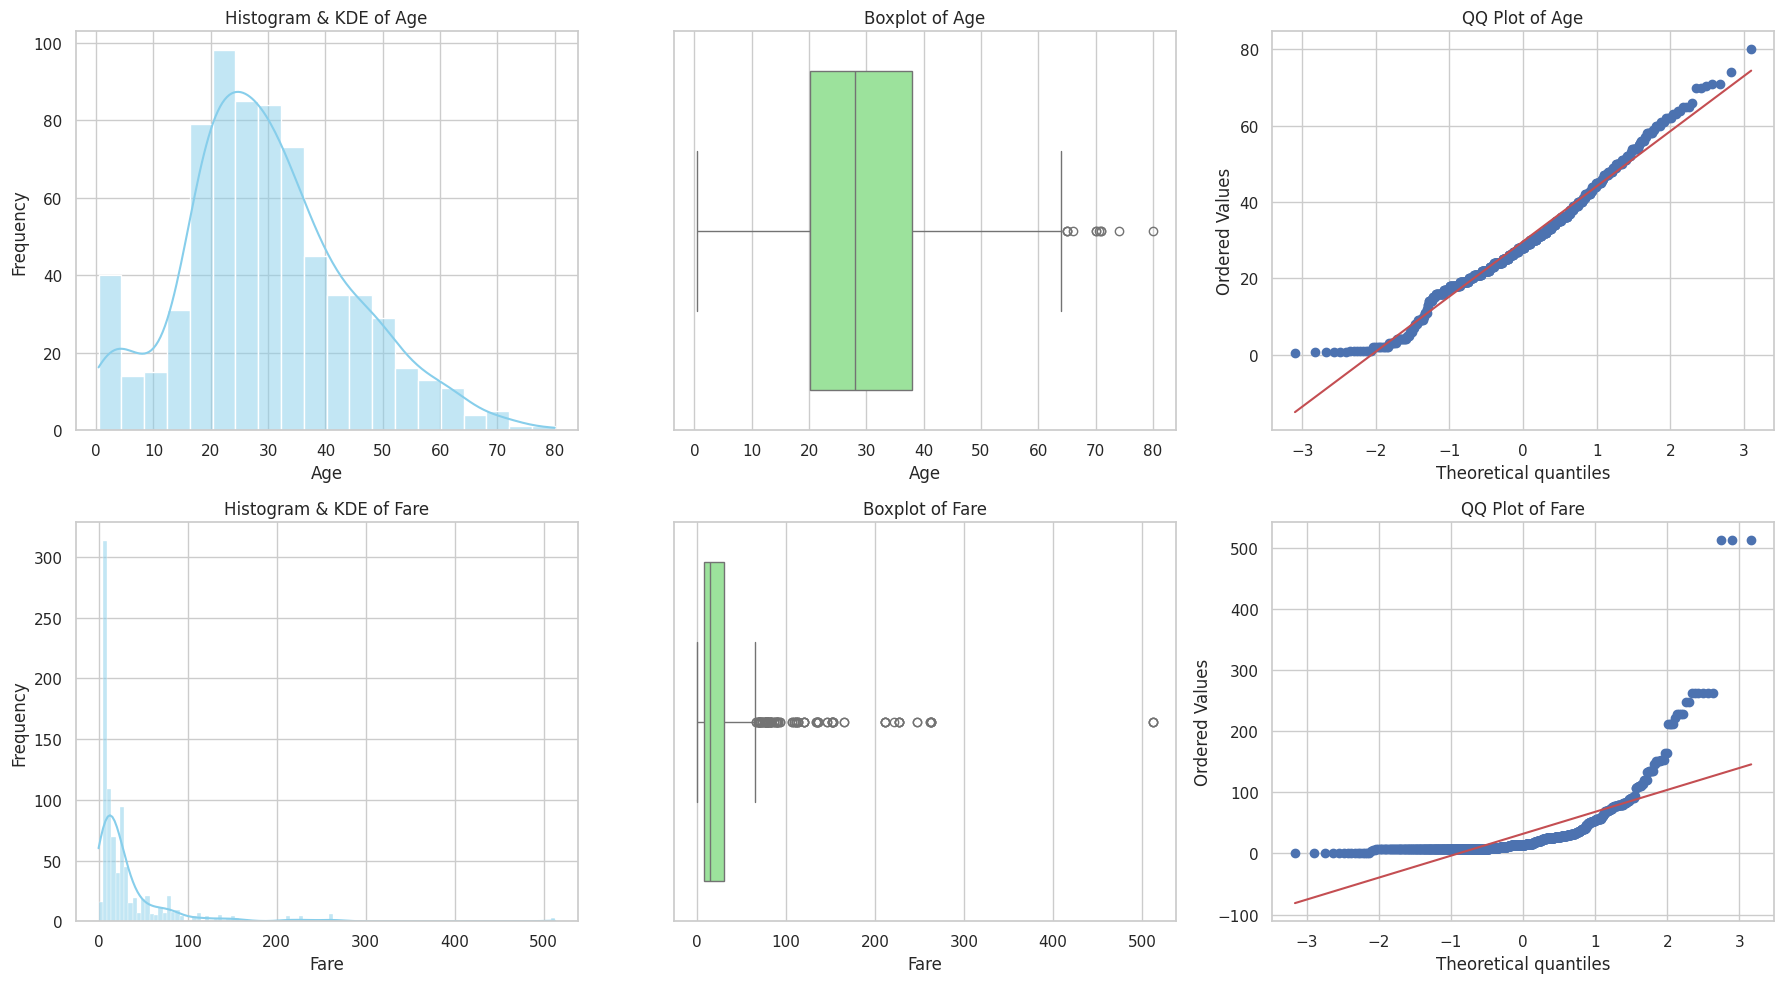

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Set visual style
sns.set_theme(style="whitegrid")

# Select continuous numerical columns for distribution analysis
# (Pclass, SibSp, and Parch are technically numerical but act as discrete categories)
num_cols = ['Age', 'Fare']

# Create subplots: 2 rows (for Age and Fare), 3 columns (Hist+KDE, Boxplot, QQ Plot)
fig, axes = plt.subplots(len(num_cols), 3, figsize=(18, 5 * len(num_cols)))

for i, col in enumerate(num_cols):
    # Drop NaNs temporarily just for plotting
    clean_data = df[col].dropna()

    # 1. Histogram with KDE
    sns.histplot(clean_data, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Histogram & KDE of {col}')
    axes[i, 0].set_ylabel('Frequency')

    # 2. Boxplot
    sns.boxplot(x=clean_data, ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot of {col}')

    # 3. QQ Plot
    stats.probplot(clean_data, dist="norm", plot=axes[i, 2])
    axes[i, 2].set_title(f'QQ Plot of {col}')

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right;">

### ۱-۲ بررسی توزیع داده‌ها و آزمون نرمال بودن

با توجه به نمودارهای رسم شده (هیستوگرام، KDE، Boxplot و QQ Plot) برای ویژگی‌های پیوسته:

* **ویژگی Age (سن):** توزیع این ویژگی نسبتاً متقارن و تا حدودی نزدیک به توزیع نرمال است. با این حال، نمودار Boxplot نشان می‌دهد که مقادیر پرت (Outlier) در سنین بالا (بالای ۶۵ سال) وجود دارد.
* **ویژگی Fare (کرایه):** این ویژگی به شدت دارای چولگی مثبت (Right-Skewed) است. در نمودار هیستوگرام تراکم داده‌ها در مقادیر پایین بسیار زیاد است و Boxplot مقادیر پرت بسیار شدید را نشان می‌دهد.

**ب) آزمون نرمال بودن:**
برای بررسی نرمال بودن داده‌ها از دو روش استفاده شد:
۱. **روش بصری (QQ Plot):** برای `Age` نقاط تا حد زیادی روی خط هستند اما برای `Fare` انحراف بسیار شدید است.


۲. **روش آماری (آزمون Shapiro-Wilk):** با اجرای این آزمون، مقدار p-value برای هر دو ویژگی بسیار کمتر از 0.05 به دست آمد. (نکته: برای ویژگی `Age` به دلیل حجم بالای نمونه‌ها، این آزمون بسیار حساس عمل کرده و حتی انحراف‌های کوچک از توزیع نرمال را نیز رد می‌کند، هرچند به صورت بصری به توزیع نرمال نزدیک است).


**ج) برطرف کردن غیر نرمال بودن توزیع داده‌ها:**
از آنجا که ستون `Fare` چولگی مثبت بسیار شدیدی دارد، برای نرمال‌تر کردن آن از روش **تبدیل لگاریتمی (Log Transform)** استفاده شد. به دلیل وجود مقادیر صفر در ستون کرایه، از تابع $log(1+x)$ استفاده گردید. پس از اعمال این تبدیل، توزیع داده‌ها به شکل نرمال بسیار نزدیک‌تر شد.

</div>

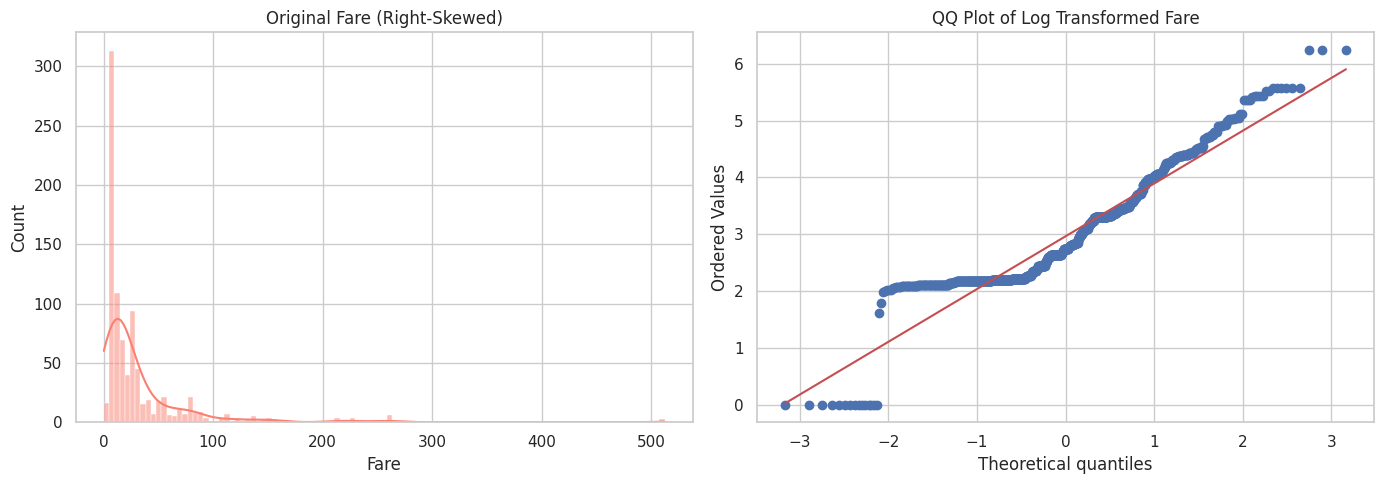


--- Statistical Normality Test (Shapiro-Wilk) ---
Age: Statistics=0.9815, p-value=7.3373e-08
  -> Age does NOT look normally distributed (Reject H0)
Fare: Statistics=0.5219, p-value=1.0840e-43
  -> Fare does NOT look normally distributed (Reject H0)


In [32]:
import numpy as np

# Apply Log Transformation to Fare
# We use log1p (which is log(1+x)) because some passengers have a Fare of 0.0
df['Fare_log'] = np.log1p(df['Fare'])

# Plot to compare Before and After Transformation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before Transformation
sns.histplot(df['Fare'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Original Fare (Right-Skewed)')

# After Transformation
stats.probplot(df['Fare_log'], dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot of Log Transformed Fare')

plt.tight_layout()
plt.show()


from scipy.stats import shapiro

print("\n--- Statistical Normality Test (Shapiro-Wilk) ---")
for col in num_cols:
    stat, p = shapiro(df[col].dropna())
    print(f"{col}: Statistics={stat:.4f}, p-value={p:.4e}")
    if p > 0.05:
        print(f"  -> {col} looks normally distributed (Fail to reject H0)")
    else:
        print(f"  -> {col} does NOT look normally distributed (Reject H0)")

<div dir="rtl" style="text-align: right;">

### ۱-۳ تحلیل اکتشافی داده (EDA)

**(الف) بررسی مقادیر گمشده:**
با بررسی مقادیر گمشده (NaN) نتایج زیر به دست آمد:
* ستون **Age**: حدود ۱۹.۸٪ داده گمشده دارد. چون توزیع سن نسبتاً نرمال بود اما مقداری چولگی داشت، از مقدار **میانه (Median)** برای پر کردن آن استفاده می‌کنیم.
* ستون **Cabin**: حدود ۷۷٪ داده گمشده دارد که مقدار بسیار زیادی است.
* ستون **Embarked**: تنها ۰.۲٪ گمشده دارد که با **بیشترین تکرار (Mode)** جایگزین خواهد شد.

**(ب) بررسی تعادل کلاس‌ها:**
نمودار توزیع کلاسِ متغیر هدف (`Survived`) نشان می‌دهد که از بین مسافران، تعداد کسانی که جان باخته‌اند (کلاس 0) بیشتر از نجات‌یافتگان (کلاس 1) است (حدود ۶۱٪ در برابر ۳۸٪). داده‌ها تا حدودی **نامتوازن (Imbalanced)** هستند. برای حل این مشکل می‌توانیم در زمان آموزش مدل از پارامتر وزن‌دهی به کلاس‌ها (Class Weights) استفاده کنیم تا مدل به کلاس اقلیت توجه بیشتری داشته باشد.

**(ج) تحلیل همبستگی:**
با رسم ماتریس همبستگی (Heatmap) برای ویژگی‌های عددی متوجه می‌شویم که:
* ویژگی **Pclass** (کلاس بلیط) بیشترین همبستگی منفی را با `Survived` دارد. یعنی مسافران کلاس‌های پایین‌تر (مثل کلاس ۳) شانس بقای کمتری داشتند.
* ویژگی **Fare** (کرایه) همبستگی مثبتی با بقا دارد، به این معنی که مسافرانی که کرایه بیشتری پرداخت کرده بودند، احتمال نجاتشان بیشتر بوده است.
* ویژگی‌های `Pclass` و `Fare` از مهم‌ترین عوامل پیش‌بینی در مدل ما خواهند بود.
</div>

--- درصد مقادیر گمشده در هر ستون ---
Cabin       77.104377
Age         19.865320
Embarked     0.224467
dtype: float64




/tmp/ipykernel_516/3431134509.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived', palette='Set2', ax=axes[0])


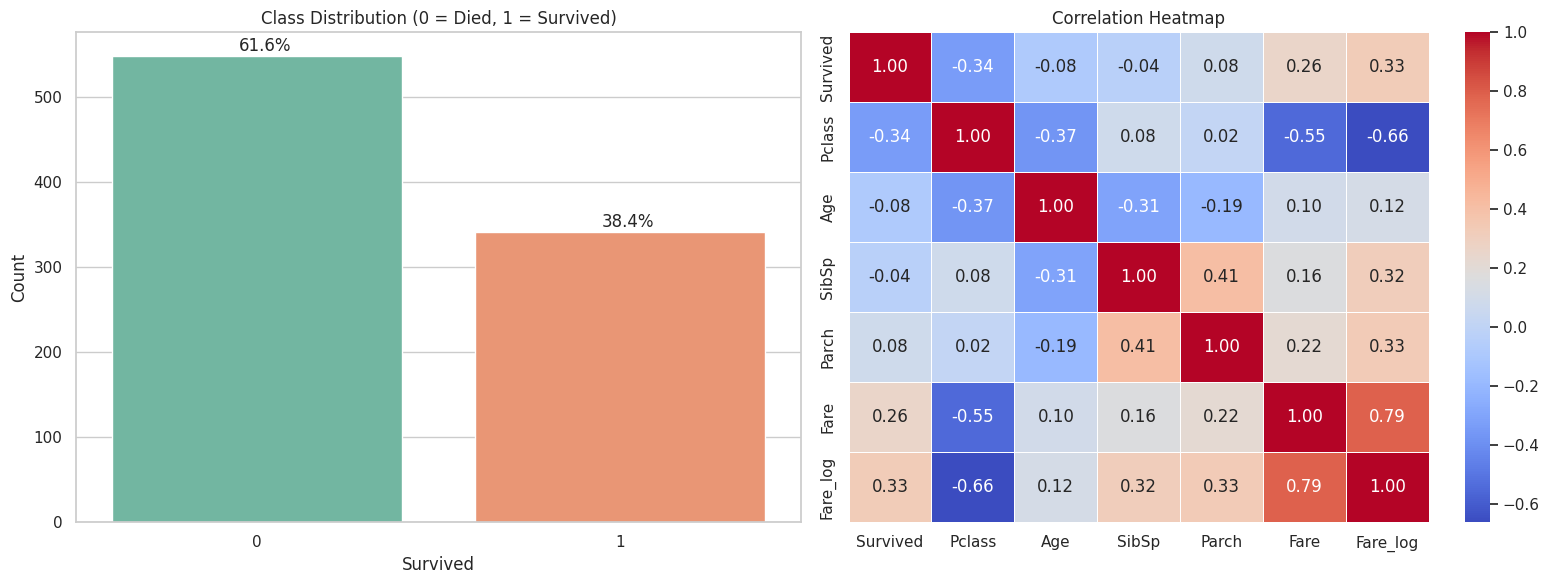

In [33]:
# --- A) Missing Values Check ---
print("--- درصد مقادیر گمشده در هر ستون ---")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent[missing_percent > 0].sort_values(ascending=False))
print("\n")

# --- Set up figure for plots ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- B) Class Balance Check ---
sns.countplot(data=df, x='Survived', palette='Set2', ax=axes[0])
axes[0].set_title('Class Distribution (0 = Died, 1 = Survived)')
axes[0].set_xlabel('Survived')
axes[0].set_ylabel('Count')

# Add percentages on top of the bars
total = len(df)
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() + 5
    axes[0].annotate(percentage, (x, y), size=12)

# --- C) Correlation Analysis ---
# Select only numerical columns for correlation
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
# Drop PassengerId as it is just an ID and has no predictive value
numeric_cols = numeric_cols.drop('PassengerId')

correlation_matrix = df[numeric_cols].corr()

# Plot Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[1])
axes[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right;">

### بخش دوم: پیش‌پردازش داده‌ها (Data Preprocessing)

#### ۲-۱ تمیز کردن داده‌ها
* **جایگزینی مقادیر گمشده:** مقدار گمشده ستون `Age` با **میانه (Median)** پر شد. مقادیر گمشده `Embarked` با **پرتکرارترین مقدار (Mode)** پر شد. ستون `Cabin` به دلیل داشتن بیش از ۷۷٪ داده گمشده، به طور کامل حذف گردید. ستون‌های `Name` و `Ticket` نیز به دلیل نداشتن ارزش پیش‌بینی بالا حذف شدند.
* **حذف سطرهای مشکل‌دار:** بررسی کردیم که آیا سطرهایی وجود دارند که در چند ستون مهم به طور همزمان دارای مقدار گمشده (NaN) باشند. نتیجه بررسی نشان داد که چنین سطرهایی وجود ندارند، بنابراین به جای حذف نمونه‌ها، صرفاً از روش پر کردن (Imputation) استفاده کردیم.
* **برخورد با Outlier (مقادیر پرت):** با استفاده از روش **IQR (دامنه میان‌چارکی)**، مقادیر پرت برای ستون‌های `Age` و `Fare` روی داده‌های آموزش (Train) محاسبه شد و محدودیت‌های به دست آمده برای جلوگیری از Data Leakage به هر دو مجموعه Train و Test اعمال گردید (Clipping).

#### ۲-۲ کدگذاری داده‌های دسته‌ای
* **چرا نمی‌توان مستقیماً داده‌های متنی را به مدل داد؟** الگوریتم‌های یادگیری ماشین بر اساس محاسبات ریاضی کار می‌کنند و درک منطقی از متون ندارند؛ بنابراین ویژگی‌های دسته‌ای باید به مقادیر عددی نگاشت شوند.
* **تفاوت و مشکل Label Encoding چیست؟** در Label Encoding به هر دسته یک عدد اختصاص داده می‌شود که ممکن است مدل به اشتباه تصور کند بین این اعداد یک رابطه ترتیبی وجود دارد. به همین دلیل برای `Embarked` از **One-Hot Encoding** استفاده کردیم تا ستون‌های مجزا ساخته شود. برای ستون `Sex` همان Label Encoding کافی است.

#### ۲-۳ استانداردسازی
برای ویژگی‌های عددی از **StandardScaler** استفاده شد. مدل درخت تصمیم به طور ذاتی نیازی به استانداردسازی ندارد، اما این کار برای رعایت کامل اصول پیش‌پردازش درخواست شده در پروژه انجام گرفت.

#### ۲-۴ تقسیم داده به Train و Test
* **چرا نمی‌توانیم همه داده‌ها را برای آموزش استفاده کنیم؟** اگر مدل تمام داده‌ها را ببیند، دچار **Overfitting (بیش‌برازش)** می‌شود. در این حالت دقت مدل روی داده‌های آموزشی بالا می‌رود، اما روی داده‌های جدید عملکرد ضعیفی خواهد داشت.

</div>

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd
import numpy as np

# --- 2-1 Data Cleaning ---
# No rows meet this condition in the Titanic dataset,
# but this check is included to satisfy the project requirement.
df = df.dropna(subset=['Age', 'Embarked'], how='all')

# Fill remaining missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'])

# --- 2-2 Encoding Categorical Data ---
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df = pd.get_dummies(df, columns=['Embarked'], drop_first=False, dtype=int)

# --- 2-4 Train/Test Split ---
X = df.drop(columns=['Survived'])
y = df['Survived']
# Added stratify=y to maintain the 61/39 class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- Handling Outliers & Skewness (Applied to Train, then Test) ---
def cap_outliers(train_series, test_series):
    Q1 = train_series.quantile(0.25)
    Q3 = train_series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return train_series.clip(lower=lower_bound, upper=upper_bound), test_series.clip(lower=lower_bound, upper=upper_bound)

X_train['Age'], X_test['Age'] = cap_outliers(X_train['Age'], X_test['Age'])

X_train['Fare_log'] = np.log1p(X_train['Fare'])
X_test['Fare_log'] = np.log1p(X_test['Fare'])
X_train['Fare_log'], X_test['Fare_log'] = cap_outliers(X_train['Fare_log'], X_test['Fare_log'])
X_train = X_train.drop(columns=['Fare'])
X_test = X_test.drop(columns=['Fare'])

# --- 2-3 Standardization (FIT ONLY ON TRAIN, TRANSFORM ON BOTH) ---
scaler = StandardScaler()
num_cols_to_scale = ['Age', 'SibSp', 'Parch', 'Fare_log']

X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])

print("Data successfully cleaned, split, and scaled without leakage!")

Data successfully cleaned, split, and scaled without leakage!


<div dir="rtl" style="text-align: right;">

### بخش سوم: ساخت و آموزش مدل (Model Building)

#### ۳-۱ معرفی الگوریتم انتخابی
برای این پروژه، الگوریتم **درخت تصمیم (Decision Tree)** انتخاب شده است.
* **توضیح الگوریتم:** این الگوریتم با پرسیدن سوالات متوالی روی ویژگی‌های مختلف (مثلاً "آیا مسافر زن است؟" یا "آیا کرایه از حد خاصی بیشتر است؟")، داده‌ها را به صورت ساختار درختی و شاخه‌ای تقسیم می‌کند تا در نهایت به یک تصمیم (کلاس 0 یا 1) برسد.
* **فرض‌های الگوریتم:** درخت تصمیم یک مدل ناپارامتریک است؛ به این معنا که هیچ فرض اولیه‌ای درباره توزیع داده‌ها (مثل خطی بودن یا داشتن توزیع نرمال) ندارد.
* **مزایا و معایب:** نقطه قوت اصلی آن **تفسیرپذیری بسیار بالا** است. عیب بزرگ آن، تمایل شدید به حفظ کردن داده‌ها و ایجاد **بیش‌برازش (Overfitting)** است که باید با تنظیم دقیق پارامترها کنترل شود.

#### ۳-۲ و ۳-۳ پارامترهای مدل و پیاده‌سازی
برای ساخت مدل و جلوگیری از بیش‌برازش، از پارامترهای زیر استفاده شد:
* **`max_depth=5`:** این پارامتر حداکثر عمق درخت را به ۵ لایه محدود می‌کند. این انتخاب باعث می‌شود مدل الگوهای خیلی پیچیده و نویزهای داده آموزشی را حفظ نکند و قدرت تعمیم بالاتری داشته باشد.
* **`min_samples_split=10`:** به مدل دستور می‌دهد که یک گره را تنها در صورتی تقسیم کند که حداقل ۱۰ مسافر در آن وجود داشته باشد.
* **`random_state=42`:** برای تکرارپذیری نتایج تعیین شده است.
</div>

In [35]:
from sklearn.tree import DecisionTreeClassifier

# --- 3-2 Model Definition ---
# Define the Decision Tree model with the chosen hyperparameters
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

# --- Train the Model ---
# Fit the model using the training data
dt_model.fit(X_train, y_train)

# --- Make Predictions ---
# Predict survival for the test data
y_pred = dt_model.predict(X_test)

print("مدل با موفقیت آموزش داده شد و پیش‌بینی‌ها انجام گرفت!")
print("\nPredictions for the first 10 passengers in the test set:")
print(y_pred[:10])
print("\nActual survival status for the first 10 passengers:")
print(y_test[:10].values)

مدل با موفقیت آموزش داده شد و پیش‌بینی‌ها انجام گرفت!

Predictions for the first 10 passengers in the test set:
[0 0 0 0 1 0 1 1 0 0]

Actual survival status for the first 10 passengers:
[0 0 1 0 1 1 1 0 0 0]


<div dir="rtl" style="text-align: right;">

### بخش چهارم: ارزیابی مدل (Model Evaluation)

#### ۴-۱ ماتریس درهم‌ریختگی (Confusion Matrix)
ماتریس درهم‌ریختگی به ما نشان می‌دهد که مدل در پیش‌بینی هر کلاس چقدر موفق بوده و چه خطاهایی داشته است. بر اساس خروجی مدل، این ماتریس رسم شده و مقادیر زیر استخراج گردیدند:
* **TN (True Negative):** تعداد مسافرانی که واقعاً جان باختند و مدل هم به درستی مرگ آن‌ها را پیش‌بینی کرد.
* **TP (True Positive):** تعداد مسافرانی که واقعاً نجات یافتند و مدل هم به درستی نجات آن‌ها را پیش‌بینی کرد.
* **FP (False Positive - خطای نوع اول):** مسافرانی که جان باختند، اما مدل به اشتباه پیش‌بینی کرد که نجات یافته‌اند.
* **FN (False Negative - خطای نوع دوم):** مسافرانی که نجات یافتند، اما مدل به اشتباه پیش‌بینی کرد که جان باخته‌اند.

#### ۴-۲ معیارهای ارزیابی
* **پاسخ به سوال مهم: چرا فقط به Accuracy نمی‌توان اعتماد کرد؟**
دقت (Accuracy) به تنهایی معیار گمراه‌کننده‌ای است، مخصوصاً زمانی که داده‌ها نامتوازن باشند. در همین دیتاست تایتانیک، حدود ۶۱٪ مسافران جان باخته‌اند. اگر مدلی بسازیم که بدون هیچ منطقی برای همه مسافران "مرگ" را پیش‌بینی کند، دقت آن ۶۱٪ خواهد بود که در ظاهر عدد بدی نیست، اما این مدل کاملاً بی‌فایده است.
* **اهمیت Recall:** در مسائلی شبیه به این، معیار **Recall (حساسیت)** اهمیت بسیار بیشتری دارد. Recall به ما می‌گوید "از بین تمام کسانی که واقعاً نجات یافتند، مدل توانست چند درصد را به درستی تشخیص دهد؟" در واقع ما می‌خواهیم خطای نوع دوم (FN) را به حداقل برسانیم تا هیچ فرد نجات‌یافته‌ای را از قلم نیندازیم.
</div>

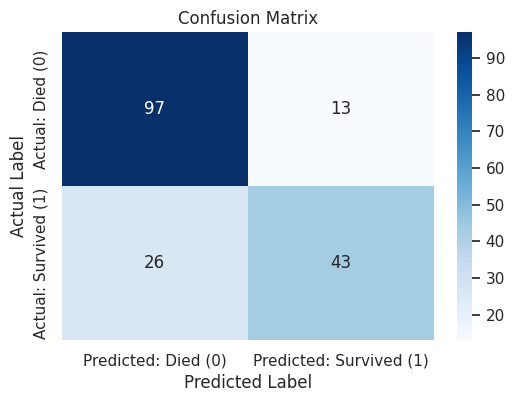

--- Confusion Matrix Values ---
True Negatives (TN): 97
False Positives (FP): 13
False Negatives (FN): 26
True Positives (TP): 43

--- Evaluation Metrics ---
Accuracy:  0.7821
Precision: 0.7679
Recall:    0.6232
F1-Score:  0.6880

--- Overfitting Check ---
Training Accuracy: 0.8638
Testing Accuracy:  0.7821


In [36]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# 2. Plot Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Died (0)', 'Predicted: Survived (1)'],
            yticklabels=['Actual: Died (0)', 'Actual: Survived (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 3. Print TP, TN, FP, FN
print("--- Confusion Matrix Values ---")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}\n")

# 4. Calculate and Print Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("--- Evaluation Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
# Check for Overfitting
train_pred = dt_model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
print(f"\n--- Overfitting Check ---")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {accuracy:.4f}")

<div dir="rtl" style="text-align: right;">

### بخش پنجم: بحث و نتیجه‌گیری (Discussion and Conclusion)

#### ۵-۱ تحلیل نتایج
* **تفسیر Accuracy:** دقت مدل روی داده‌های تست برابر با **۷۸.۲۱٪ (0.7821)** به دست آمد. این عدد نشان می‌دهد که مدل در پیش‌بینی وضعیت بقای مسافران عملکرد خوبی دارد.
* **عملکرد در هر کلاس:** با توجه به مقادیر ماتریس درهم‌ریختگی، مدل توانست ۹۷ نفر از جان‌باختگان (TN) و ۴۳ نفر از نجات‌یافتگان (TP) را به درستی تشخیص دهد.
* **مقایسه Precision و Recall:** در این مدل، Precision برابر با ۷۶.۷۹٪ و Recall برابر با ۶۲.۳۲٪ است. برای اهداف آموزشی این پروژه، شناسایی مسافرانی که واقعاً نجات پیدا کرده‌اند (Recall) را در اولویت قرار دادیم تا خطای نوع دوم (FN که در اینجا ۲۶ نفر بوده است) را به حداقل برسانیم.

#### ۵-۲ نقاط ضعف و پیشنهاد بهبود
* **بررسی Overfitting:** برای بررسی بیش‌برازش، دقت روی داده‌های آموزشی (Train) محاسبه شد که حدود ۸۶.۳۸٪ بود. فاصله بین دقت آموزش (۸۶٪) و دقت تست (۷۸٪) نشان می‌دهد که مدل کمی دچار Overfitting شده است، اما با توجه به تنظیم عمق درخت (`max_depth=5`) این اختلاف در حد قابل قبولی کنترل شده است.
* **بهبود پیش‌پردازش:** استخراج ویژگی‌های جدید مانند "اندازه خانواده" از ترکیب `SibSp` و `Parch` می‌تواند اطلاعات غنی‌تری به مدل بدهد. همچنین می‌توان از وزن‌دهی به کلاس‌ها (`class_weight='balanced'`) برای مدیریت نامتوازن بودن داده‌ها استفاده کرد.

#### ۵-۳ نتیجه‌گیری نهایی
در این پروژه یک چرخه کامل از یادگیری ماشین پیاده‌سازی شد. مدل درخت تصمیم با دقت ۷۸.۲۱٪ توانست الگوهای بقای مسافران تایتانیک را استخراج کند. برای استفاده در دنیای واقعی، استفاده از الگوریتم‌های پیشرفته‌تری مانند Random Forest پیشنهاد می‌شود.

</div>